## sequential workflow

In [40]:
# step 1: import necessary modules
from typing_extensions import TypedDict # for Python versions < 3.8 or use 'from typing import TypedDict' for Python 3.8+
from langgraph.graph import StateGraph,  START, END


In [41]:
# step 2:Initialize the chat model
import os 
from dotenv import load_dotenv 
load_dotenv()

from langchain.chat_models import init_chat_model
api_key = os.getenv("GOOGLE_API_KEY")

chat_model= init_chat_model (
    "google_genai:gemini-flash-latest", 
    api_key=api_key,
    temperature=0.7
)


In [42]:

#step 3:define state
class QuestionAnsweringState(TypedDict):
    question: str
    answer: str

In [43]:
# step 4 :define node function
def question_answering_step(state: QuestionAnsweringState) -> QuestionAnsweringState:
    question=state['question']
    prompt=f"Answer the following question: {question}"
    answer=chat_model.invoke(prompt).content
    state['answer']=answer
    return state

In [ ]:
#step 6 : define graph 
#step 6.1 initialize graph with state type
graph=StateGraph(QuestionAnsweringState)
#step 6.2 add nodes
graph.add_node('question_answering_step',question_answering_step)
#step 6.3 define edges
graph.add_edge(START,'question_answering_step')
# step 6.3 define edges 
graph.add_edge('question_answering_step',END)
#step 6.4 compile graph to workflow
workflow=graph.compile()
# step 7: invoke workflow with initial state
initial_state={'question':'capital of jharkhand and explain about it in brief like tour guide would do'}
# step 7.1 invoke workflow with initial state
final_state=workflow.invoke(initial_state)
# step 7.2: print final state answer
print (final_state['answer'])
#print (final_state)# return the entire state dictionary

The capital of Jharkhand is **Ranchi**.

Here is a brief explanation about it, delivered in the style of a tour guide:

***

"Welcome, travelers, to **Ranchi**! Often known as the **'City of Waterfalls'**, Ranchi isn't just the administrative heart of Jharkhand—it's a breathtaking escape nestled right in the Chota Nagpur Plateau.

Now, why should you linger here?

Firstly, the **climate** is delightful. Because of its elevation, Ranchi enjoys relatively pleasant weather, making it a popular choice for people looking to escape the heat of the plains.

But the real showstoppers here are the **waterfalls**. Just a short drive out, you can chase the mist at magnificent spots like **Hundru Falls**—where the Subarnarekha River dramatically plummets hundreds of feet—or the serene **Jonha Falls (Gautam Dhara)**. And don't miss **Dassam Falls**, a powerful cascade perfect for that stunning photo op!

When you're back in the city, take a moment to visit the **Ranchi Hill** and the **Jagannath Te

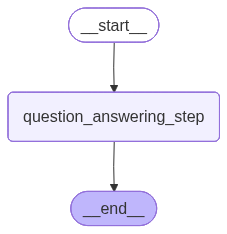

In [6]:
#visualize graph method 1
graph.compile()

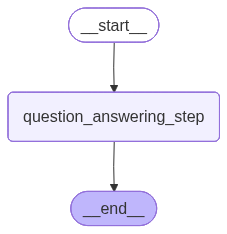

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png()) #method 2 visualize

## parallel workflow

In [8]:
from typing import TypedDict
from langgraph.graph import  StateGraph, START,END
from langchain.chat_models import init_chat_model
import os 
from dotenv import load_dotenv

load_dotenv()

api_key=os.getenv ("GOOGLE_API_KEY")

llm=init_chat_model(
    "google_genai:gemini-flash-latest",
    api_key=api_key,
    temperature=0.7
)

In [9]:
#using parallel workflow making a tour plan for a city in which different node will be merged to give final output
class TourPlanState(TypedDict):
    cities:str
    food:str
    places:str
    finalplan:str


In [10]:
#defing node functions to implement the parallel steps
def get_city_step(state:TourPlanState)->TourPlanState:
    prompt="Provide a top 3 popular tourist city in India."
    cities=llm.invoke(prompt).content
    state['cities']=cities
    return {"cities": cities}

def get_food_step(state:TourPlanState)->TourPlanState:
    cities=state['cities']
    prompt=f"provide a top 3 popular foods to try in {cities}."
    food=llm.invoke(prompt).content
    state['food']=food
    return {"food": food}

def get_places_step(state:TourPlanState)->TourPlanState:
    cities=state['cities']
    prompt=f"List some must-visit places in {cities}."
    places=llm.invoke(prompt).content
    state['places']=places
    return {"places": places}

def compile_plan_step(state:TourPlanState)->TourPlanState:
    cities=state['cities']
    food=state['food']
    places=state['places']
    prompt=f"Create a tour plan for {cities} including the following foods: {food} and places: {places}."
    finalplan=llm.invoke(prompt).content
    state['finalplan']=finalplan
    return {"finalplan": finalplan}


In [48]:
graph = StateGraph(TourPlanState)
graph.add_node('get_city_step',get_city_step)
graph.add_node('get_food_step',get_food_step)
graph.add_node('get_places_step',get_places_step)
graph.add_node('compile_plan_step',compile_plan_step)

graph.add_edge(START,'get_city_step')
graph.add_edge('get_city_step','get_food_step') 
graph.add_edge('get_city_step','get_places_step')
graph.add_edge('get_food_step','compile_plan_step')
graph.add_edge('get_places_step','compile_plan_step')
graph.add_edge ('compile_plan_step',END)

workflow=graph.compile()
initial_state={'cities':'','food':'','places':'','finalplan':''}
final_state=workflow.invoke(initial_state)
print(final_state['finalplan'])


This tour plan focuses on the famous **Golden Triangle** circuit, allocating 7 days (6 nights) to comfortably cover the extensive list of historical sites and ensure time is dedicated to experiencing the unique culinary offerings of each city.

---

## The Golden Triangle: 7 Days / 6 Nights Tour Plan

| City | Duration | Focus |
| :--- | :--- | :--- |
| **Delhi** | 2 Nights | Historical contrast (Old vs. New Delhi) and culinary melting pot. |
| **Agra** | 1 Night | Mughal architecture and the Taj Mahal. |
| **Jaipur** | 3 Nights | Rajput royalty, majestic forts, and Rajasthani desert cuisine. |

---

## Day 1: Arrival in Delhi & The Heritage of Old Delhi

**Theme:** Mughal History, Bustling Bazaars, and Street Food.

| Time | Activity | Place/Experience | Food Goal |
| :--- | :--- | :--- | :--- |
| **Morning** | Arrival & Check-in | Arrive at Indira Gandhi International Airport (DEL). Transfer to the hotel (preferably Central or South Delhi). | Standard hotel breakfast. |
| **Afternoon

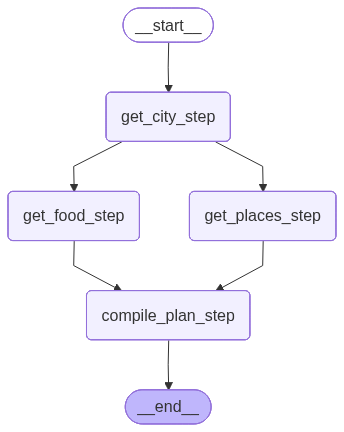

In [12]:
graph.compile()

## conditional workflow 

In [30]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [31]:
class SentimentAnalysisState(TypedDict):
    text: str
    sentiment: str
    response_type: str


In [32]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("GOOGLE_API_KEY")

llm = init_chat_model(
    "google_genai:gemini-flash-latest",
    api_key=api_key
)


In [33]:
def sentiment_checker(state: SentimentAnalysisState):
    prompt = f"""
    Classify the sentiment of the following text as:
    positive, very positive, negative, very negative, or neutral.

    Text: {state['text']}
    """
    sentiment = llm.invoke(prompt).content.strip().lower()
    return {"sentiment": sentiment}


In [34]:
def categorize_sentiment(sentiment: str) -> str:
    if sentiment in ["positive", "very positive"]:
        return "positive"
    elif sentiment in ["negative", "very negative"]:
        return "negative"
    else:
        return "neutral"


In [35]:
def route_sentiment(state: SentimentAnalysisState):
    category = categorize_sentiment(state["sentiment"])
    return category


In [36]:
def positive_response(state: SentimentAnalysisState):
    return {"response_type": "positive"}

def negative_response(state: SentimentAnalysisState):
    return {"response_type": "negative"}

def neutral_response(state: SentimentAnalysisState):
    return {"response_type": "neutral"}


In [37]:
graph = StateGraph(SentimentAnalysisState)

# Nodes
graph.add_node("sentiment_checker", sentiment_checker)
graph.add_node("positive", positive_response)
graph.add_node("negative", negative_response)
graph.add_node("neutral", neutral_response)

# Flow
graph.add_edge(START, "sentiment_checker")

# Conditional routing
graph.add_conditional_edges(
    "sentiment_checker",
    route_sentiment,
    {
        "positive": "positive",
        "negative": "negative",
        "neutral": "neutral",
    }
)

graph.add_edge("positive", END)
graph.add_edge("negative", END)
graph.add_edge("neutral", END)

workflow = graph.compile()


In [ ]:
text = "I am feeling great today!"

initial_state = {
    "text": text,
    "sentiment": "",
    "response_type": ""
}

final_state = workflow.invoke(initial_state)

print(final_state["response_type"])


KeyError: 'question'

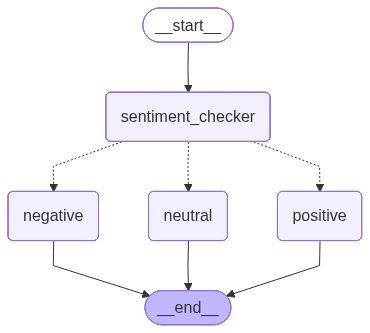

In [39]:
graph.compile()

## iterative workflow

In [49]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [50]:
from typing import TypedDict

class ShortenState(TypedDict):
    text: str
    word_count: int


In [51]:
def shorten_text(state: ShortenState):
    prompt = f"Shorten this text to fewer words:\n{state['text']}"
    new_text = llm.invoke(prompt).content.strip()

    return {
        "text": new_text,
        "word_count": len(new_text.split())
    }

In [ ]:
def check_length(state: ShortenState):
    if state["word_count"] <= 10:
        return "exit"
    else:
        return "continue"


In [53]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ShortenState)

graph.add_node("shorten", shorten_text)

graph.add_edge(START, "shorten")

graph.add_conditional_edges(
    "shorten",
    check_length,
    {
        "continue": "shorten",  # 🔁 loop
        "exit": END
    }
)

app = graph.compile()


In [54]:
initial_state = {
    "text": "LangGraph allows you to build complex agent workflows easily",
    "word_count": 100
}

final_state = app.invoke(initial_state)
print(final_state["text"])


LangGraph simplifies agent workflows.


In [5]:
#example 2 iterative workflow 
#count 1 to 5 

In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [ ]:
class counterstate (TypedDict):
    count : int 

In [32]:
def increment_value (state:counterstate):
    increment=state["count"]+1
    return {"count":increment}

In [ ]:
def check_count(state: counterstate):
    if state["count"] <5:
        return "continue"
    else :
        return "exit"

In [35]:
graph=StateGraph(counterstate)
graph.add_node ("incrementing_node",increment_value)
graph.add_edge (START,"incrementing_node")
graph.add_conditional_edges("incrementing_node",
                            check_count,
                            {
                                "continue":"incrementing_node",
                                "exit": END
                            }
                            )

workflow = graph.compile()

In [36]:
initial_state = {"count": 1}

final_state = workflow.invoke(initial_state)

print(final_state)


{'count': 5}


## Streaming Example
streaming is a method in which we can see partinal or internal output of the llm working before the actual final output

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain.schema import HumanMessage
import os
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
class LLMState(TypedDict):
    question: str
    answer: str


In [3]:
llm = init_chat_model(
    "google_genai:gemini-2.5-flash",
    api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.3,
)


d:\langgraphcourse\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def llm_node(state: LLMState):
    response = llm.invoke(
        [HumanMessage(content=state["question"])]
    )
    return {"answer": response.content}


In [5]:
graph = StateGraph(LLMState)

graph.add_node("llm_node", llm_node)
graph.add_edge(START, "llm_node")
graph.add_edge("llm_node", END)

workflow = graph.compile()


In [7]:
initial_state = {
    "question": "Explain the jhrakhand tourism",
    "answer": ""
}

for chunk in workflow.stream(
    initial_state,
    stream_mode="messages"
):
    print(chunk)


(AIMessageChunk(content='Jharkhand, often referred to as the **', additional_kwargs={}, response_metadata={'safety_ratings': []}, id='run--f7df4679-ddd6-4e70-bbd8-b5abb5267764', usage_metadata={'input_tokens': 7, 'output_tokens': 9, 'total_tokens': 1310, 'input_token_details': {'cache_read': 0}}), {'langgraph_step': 1, 'langgraph_node': 'llm_node', 'langgraph_triggers': ('branch:to:llm_node',), 'langgraph_path': ('__pregel_pull', 'llm_node'), 'langgraph_checkpoint_ns': 'llm_node:3f01723d-504e-84ac-9795-474ed4300d23', 'checkpoint_ns': 'llm_node:3f01723d-504e-84ac-9795-474ed4300d23', 'ls_provider': 'google_genai', 'ls_model_name': 'models/gemini-2.5-flash', 'ls_model_type': 'chat', 'ls_temperature': 0.3})
(AIMessageChunk(content='"Land of Forests"** (its literal meaning) and the **"Land of Waterfalls,"** is a state in eastern India known for its rich natural beauty, diverse tribal culture, and significant spiritual sites. While it has historically been less explored', additional_kwargs={

In [ ]:
initial_state = {
    "question": "Explain the jhrakhand tourism",
    "answer": ""
}

final_state = workflow.invoke(initial_state)

#print(final_state)#generate full dictionary
print(final_state['answer'])

{'question': 'Explain the jhrakhand tourism', 'answer': 'Jharkhand, often called the "Land of Forests" or "Bushland," is a state in eastern India known for its rich tribal culture, vast mineral resources, and significant natural beauty. While it hasn\'t traditionally been a mainstream tourist destination, Jharkhand tourism is slowly emerging, offering a unique blend of nature, culture, and spirituality for those seeking an off-the-beaten-path experience.\n\nHere\'s a breakdown of Jharkhand tourism:\n\n### Key Pillars of Jharkhand Tourism:\n\n1.  **Nature & Wildlife:**\n    *   **Waterfalls:** Jharkhand is famous for its numerous scenic waterfalls, especially around Ranchi, earning it the nickname "City of Waterfalls." Key examples include Hundru Falls, Jonha Falls (Gautamdhara), Dassam Falls, and Sita Falls.\n    *   **Hills & Plateaus:** The Chotanagpur Plateau provides a diverse landscape of rolling hills, dense forests, and valleys. Netarhat, known as the "Queen of Chotanagpur," is 

## add messages example

In [11]:
from typing import TypedDict
from typing_extensions import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langchain.chat_models import init_chat_model
from langchain.schema import HumanMessage, AIMessage

import os
from dotenv import load_dotenv
load_dotenv()

True

In [12]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]


In [13]:
llm = init_chat_model(
    "google_genai:gemini-2.5-flash",
    api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.3
)


In [14]:
def chat_node(state: ChatState):
    response = llm.invoke(state["messages"])
    return {
        "messages": [AIMessage(content=response.content)]
    }


In [15]:
graph = StateGraph(ChatState)
graph.add_node("chat", chat_node)
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

workflow = graph.compile()


In [16]:
initial_state = {
    "messages": [
        HumanMessage(content="What is LangGraph?")
    ]
}

final_state = workflow.invoke(initial_state)

for msg in final_state["messages"]:
    print(type(msg).__name__, ":", msg.content)


HumanMessage : What is LangGraph?
AIMessage : **LangGraph** is an extension of the LangChain framework designed for building **stateful, multi-actor applications** with Large Language Models (LLMs) and other tools.

At its core, LangGraph allows you to define complex, iterative workflows as **computational graphs**. Unlike traditional LangChain "chains" which are often linear or directed acyclic graphs (DAGs), LangGraph explicitly supports **cycles (loops)** and **conditional logic**, making it ideal for building more robust and intelligent agentic systems.

Here's a breakdown of what that means:

1.  **Computational Graphs:**
    *   You define your application as a graph where:
        *   **Nodes** represent individual steps or components (e.g., an LLM call, a tool invocation, a custom Python function, a human input step).
        *   **Edges** define the transitions between these nodes. These can be simple sequential transitions or, crucially, **conditional transitions** based on t

In [ ]:
## persistence example 

In [17]:
from typing import TypedDict
from typing_extensions import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

from langchain.chat_models import init_chat_model
from langchain.schema import HumanMessage, AIMessage

import os
from dotenv import load_dotenv
load_dotenv()


True

In [18]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]


In [19]:
llm = init_chat_model(
    "google_genai:gemini-2.5-flash",
    api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.3
)

In [20]:
def chat_node(state: ChatState):
    response = llm.invoke(state["messages"])
    return {
        "messages": [AIMessage(content=response.content)]
    }


In [21]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)
graph.add_node("chat", chat_node)
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

workflow = graph.compile(checkpointer=checkpointer)

In [22]:
config = {"configurable": {"thread_id": "user-1"}}

state_1 = {
    "messages": [
        HumanMessage(content="My name is Basant")
    ]
}

output_1 = workflow.invoke(state_1, config)

print("TURN 1:")
for msg in output_1["messages"]:
    print(type(msg).__name__, ":", msg.content)


TURN 1:
HumanMessage : My name is Basant
AIMessage : Hello Basant! It's nice to meet you.


In [23]:
state_2 = {
    "messages": [
        HumanMessage(content="What is my name?")
    ]
}

output_2 = workflow.invoke(state_2, config)

print("\nTURN 2:")
for msg in output_2["messages"]:
    print(type(msg).__name__, ":", msg.content)



TURN 2:
HumanMessage : My name is Basant
AIMessage : Hello Basant! It's nice to meet you.
HumanMessage : What is my name?
AIMessage : Your name is Basant.


In [25]:
state_3 = {
    "messages": [
        HumanMessage(content="Introduce yourself to me ?")
    ]
}

output_2 = workflow.invoke(state_3, config)

print("\nTURN 3:")
for msg in output_2["messages"]:
    print(type(msg).__name__, ":", msg.content)



TURN 3:
HumanMessage : My name is Basant
AIMessage : Hello Basant! It's nice to meet you.
HumanMessage : What is my name?
AIMessage : Your name is Basant.
HumanMessage : Introduce yourself to me ?
AIMessage : Hello Basant!

I am a large language model, trained by Google.

My purpose is to assist you by answering your questions, providing information, generating creative content, and helping you with a wide range of tasks through conversation.

It's a pleasure to interact with you! How can I help you today?
